# L15a: Dynamics as Algorithms

A differential equation becomes a computation only after we choose a state representation, a time grid, and an update rule.

> **Learning objectives**
>
> - Derive explicit Euler as a discrete state update.
> - Measure step-size error against a reference solution.
> - Interpret stability through the Euler amplification factor.
> - Compare a transparent teaching implementation with a maintained adaptive solver.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week15Core` module from [`../src/Week15Core.jl`](../src/Week15Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


## Build: explicit Euler

For `du/dt = f(u,t)`, a forward finite-difference approximation gives

$$u_{k+1}=u_k+\Delta t\,f(u_k,t_k).$$

This formula is simple enough to inspect completely, and therefore useful for exposing assumptions that a library solver normally manages for us.


In [2]:
steps = [0.5, 0.1, 0.02]
decay_runs = [
    explicit_euler(decay_rhs, [1.0], (0.0, 4.0), dt; p = 1.0)
    for dt in steps
]
exact_final = exp(-4.0)
DataFrame(
    dt = steps,
    numerical_final = [run.u[end, 1] for run in decay_runs],
    exact_final = fill(exact_final, length(steps)),
    absolute_error = [abs(run.u[end, 1] - exact_final) for run in decay_runs],
)


Row,dt,numerical_final,exact_final,absolute_error
,Float64,Float64,Float64,Float64
1,0.5,0.00390625,0.0183156,0.0144094
2,0.1,0.0147809,0.0183156,0.00353476
3,0.02,0.0175879,0.0183156,0.000727692


## Stability is not the same as accuracy

Applied to `du/dt = λu`, Euler multiplies the state by `1 + λΔt` each step. The numerical trajectory decays only when the amplification magnitude is below one.


In [3]:
stability_steps = [0.5, 1.0, 2.0, 2.5, 3.0]
factors = euler_stability_factor.(-1.0, stability_steps)
DataFrame(
    dt = stability_steps,
    amplification = factors,
    stable = abs.(factors) .< 1,
)


Row,dt,amplification,stable
,Float64,Float64,Bool
1,0.5,0.5,true
2,1.0,0.0,true
3,2.0,-1.0,false
4,2.5,-1.5,false
5,3.0,-2.0,false


## Buy: compare with a maintained adaptive solver


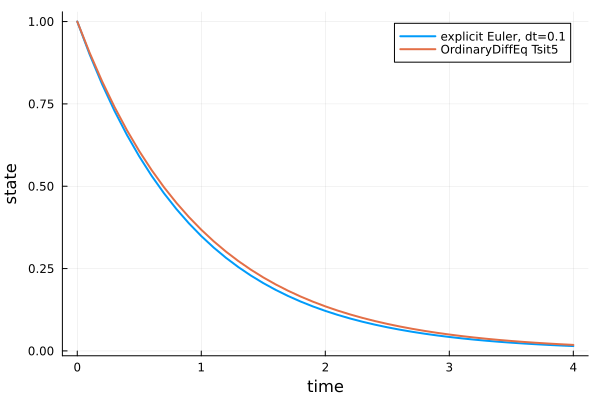

In [4]:
euler_decay = explicit_euler(decay_rhs, [1.0], (0.0, 4.0), 0.1; p = 1.0)
library_decay = library_integrate(decay_rhs, [1.0], (0.0, 4.0); p = 1.0, saveat = 0.1)
plot(
    euler_decay.t,
    euler_decay.u[:, 1];
    label = "explicit Euler, dt=0.1",
    linewidth = 2,
    xlabel = "time",
    ylabel = "state",
)
plot!(library_decay.t, library_decay.u[:, 1]; label = "OrdinaryDiffEq Tsit5", linewidth = 2)


## Adapted three-gene dynamic model

The 2024 lab's production/degradation network supplies a nonlinear engineering case. We retain the model and learning objective while replacing its isolated environment with the course root environment.


In [5]:
gene_parameters = three_gene_parameters()
gene_euler = explicit_euler(
    three_gene_rhs,
    zeros(3),
    (0.0, 60.0),
    0.1;
    p = gene_parameters,
)
gene_library = library_integrate(
    three_gene_rhs,
    zeros(3),
    (0.0, 60.0);
    p = gene_parameters,
    saveat = 0.1,
)
maximum(abs.(gene_euler.u .- gene_library.u))


0.04736640789691737

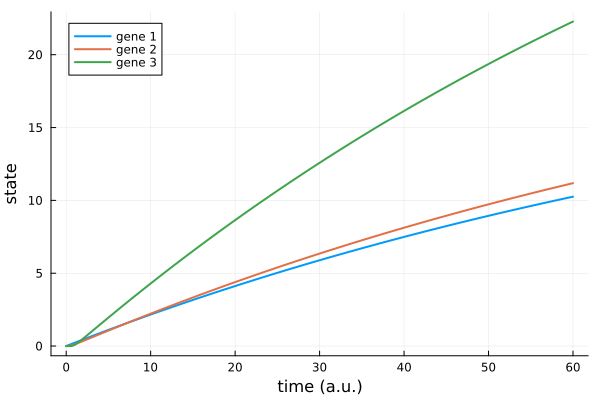

In [6]:
plot(
    gene_library.t,
    gene_library.u;
    label = ["gene 1" "gene 2" "gene 3"],
    linewidth = 2,
    xlabel = "time (a.u.)",
    ylabel = "state",
)


## Build-versus-buy conclusion

We build Euler to understand the state update, error, and stability contract. We buy a maintained solver when adaptive step selection, error control, event handling, stiffness, or broad model support matters. Understanding the algorithm improves library use; it does not justify reimplementing the library casually.
